In [1]:
import sys
sys.executable

'c:\\Users\\09048\\2026project\\icecream-sales-forecasting\\venv\\Scripts\\python.exe'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 데이터 경로
data_path = '../01_Data/raw/'

w1 = pd.read_csv(data_path + 'weather_suwon_daily01.csv', encoding='cp949')
w2 = pd.read_csv(data_path + 'weather_suwon_daily02.csv', encoding='cp949')

# 위아래로 합치기 (행 방향으로 합체)
weather = pd.concat([w1, w2], axis=0, ignore_index=True)
weather.head()

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),지면온도(°C)
0,119,수원,2021-02-01 00:00,6.8,NaN,1.1,64,NaN,0.3
1,119,수원,2021-02-01 01:00,6.6,NaN,1.2,65,NaN,0.4
2,119,수원,2021-02-01 02:00,6.3,NaN,0.6,77,NaN,0.7
3,119,수원,2021-02-01 03:00,5.9,0.3,1.1,87,NaN,0.9
4,119,수원,2021-02-01 04:00,4.6,NaN,0.4,97,NaN,1.1


In [5]:
# '일시' 컬럼을 날짜 형식으로 바꾸고 정렬
weather['일시'] = pd.to_datetime(weather['일시'])
weather = weather.sort_values(by='일시')

# 잘 정렬됐는지 확인 (제일 첫날과 마지막 날 출력)
print(f"데이터 시작일: {weather['일시'].min()}")
print(f"데이터 종료일: {weather['일시'].max()}")

데이터 시작일: 2021-02-01 00:00:00
데이터 종료일: 2022-08-01 00:00:00


In [7]:
import pandas as pd

# 1. 날짜 형식 변환 및 정렬
weather['일시'] = pd.to_datetime(weather['일시'])
weather = weather.sort_values('일시')

# 2. 날짜 정보 분리
weather['year'] = weather['일시'].dt.year
weather['month'] = weather['일시'].dt.month
weather['day'] = weather['일시'].dt.day
weather['dayofweek'] = weather['일시'].dt.dayofweek

# 3. 강수량 결측치 0으로 채우기
weather['강수량(mm)'] = weather['강수량(mm)'].fillna(0)

# 4. 불쾌지수 계산 (기온(°C)과 습도(%) 활용)
weather['불쾌지수'] = 0.81 * weather['기온(°C)'] + 0.01 * weather['습도(%)'] * (0.99 * weather['기온(°C)'] - 14.3) + 46.3

print("날씨 데이터 전처리 완료!")

날씨 데이터 전처리 완료!


In [8]:
# 기존 df
icecream = pd.read_csv(data_path + 'icecream.csv')

C:\Users\09048\AppData\Local\Temp\ipykernel_22660\2119845140.py:2: DtypeWarning: Columns (0: 신용카드승인내역_주문내역, 1: Column5, 2: Column6, 3: Column7, 4: Column12, 5: Column13, 6: Column16, 7: Column17) have mixed types. Specify dtype option on import or set low_memory=False.
  icecream = pd.read_csv(data_path + 'icecream.csv')


In [9]:
# 1행을 column으로 지정한 후 0행 삭제

icecream = icecream.rename(columns=icecream.iloc[0])
icecream = icecream.drop(icecream.index[0])
icecream.head()

,신용카드승인내역_주문내역_20230215184531.xlsx,번호,영업일자,간편결제구분,카드번호,승인번호,승인금액,할부,승인일자,승인시간,매입사,처리,기기번호,영수번호,메뉴코드,메뉴명,판매가격,판매수량
1,신용카드승인내역_주문내역_20230215184531.xlsx,1,2021-02-15,일반,944012**********,70881175,4800.0,00,2021-02-15,11:04:42,비씨카드사,정상거래,01,000002,B0000867,빼빼로바,600.0,1.0
2,신용카드승인내역_주문내역_20230215184531.xlsx,2,2021-02-15,일반,944012**********,70881175,4800.0,00,2021-02-15,11:04:42,비씨카드사,정상거래,01,000002,B0000463,초코쿠키바,400.0,1.0
3,신용카드승인내역_주문내역_20230215184531.xlsx,3,2021-02-15,일반,944012**********,70881175,4800.0,00,2021-02-15,11:04:42,비씨카드사,정상거래,01,000002,B0000705,가나 아이스바,600.0,2.0
4,신용카드승인내역_주문내역_20230215184531.xlsx,4,2021-02-15,일반,944012**********,70881175,4800.0,00,2021-02-15,11:04:42,비씨카드사,정상거래,01,000002,B0000531,체리마루바,400.0,1.0
5,신용카드승인내역_주문내역_20230215184531.xlsx,5,2021-02-15,일반,944012**********,70881175,4800.0,00,2021-02-15,11:04:42,비씨카드사,정상거래,01,000002,B0000813,빵빠레 초코,1000.0,1.0


In [10]:
# 위에서 확인한 불필요한 컬럼 삭제
icecream = icecream.drop(columns=['신용카드승인내역_주문내역_20230215184531.xlsx', '간편결제구분', '기기번호', '할부', '처리'])
icecream.head()

,번호,영업일자,카드번호,승인번호,승인금액,승인일자,승인시간,매입사,영수번호,메뉴코드,메뉴명,판매가격,판매수량
1,1,2021-02-15,944012**********,70881175,4800.0,2021-02-15,11:04:42,비씨카드사,000002,B0000867,빼빼로바,600.0,1.0
2,2,2021-02-15,944012**********,70881175,4800.0,2021-02-15,11:04:42,비씨카드사,000002,B0000463,초코쿠키바,400.0,1.0
3,3,2021-02-15,944012**********,70881175,4800.0,2021-02-15,11:04:42,비씨카드사,000002,B0000705,가나 아이스바,600.0,2.0
4,4,2021-02-15,944012**********,70881175,4800.0,2021-02-15,11:04:42,비씨카드사,000002,B0000531,체리마루바,400.0,1.0
5,5,2021-02-15,944012**********,70881175,4800.0,2021-02-15,11:04:42,비씨카드사,000002,B0000813,빵빠레 초코,1000.0,1.0


In [13]:
# 1. 데이터 타입 변환 (문자열 -> 숫자)
# errors='coerce'를 쓰면 혹시 모를 문자가 섞여있을 때 에러 대신 NaN으로 바꿔줍니다.
icecream['승인금액'] = pd.to_numeric(icecream['승인금액'], errors='coerce').fillna(0)
icecream['판매수량'] = pd.to_numeric(icecream['판매수량'], errors='coerce').fillna(0)

# 2. 아이스크림 데이터를 일별로 요약
daily_sales = icecream.groupby('영업일자').agg({
    '승인금액': 'sum',      # 이제 숫자가 되어 합산이 가능합니다!
    '승인번호': 'nunique', 
    '판매수량': 'sum'
}).reset_index()

# 3. 컬럼명 정리 및 날짜 형식 통일
daily_sales.columns = ['영업일자', 'total_sales', 'customer_count', 'total_quantity']
daily_sales['영업일자'] = pd.to_datetime(daily_sales['영업일자'])

# 4. 날씨 데이터(weather)와 병합
# 날씨 데이터 불러온 시점부터 병합까지 한 번에!
weather['일시'] = pd.to_datetime(weather['일시'])

merged_df = pd.merge(daily_sales, weather, left_on='영업일자', right_on='일시', how='left')

# 중복 날짜 컬럼 및 지점 정보 제거
merged_df = merged_df.drop(columns=['일시', '지점', '지점명'])

print("✅ 에러 없이 병합 완료!")
merged_df.head()

✅ 에러 없이 병합 완료!


,영업일자,total_sales,customer_count,total_quantity,기온(°C),강수량(mm),풍속(m/s),습도(%),일조(hr),지면온도(°C),year,month,day,dayofweek,불쾌지수
0,2021-02-15,389300.0,9,83.0,6.1,0.0,0.9,71,NaN,3.8,2021,2,15,0,45.37569
1,2021-02-16,224400.0,10,50.0,-4.1,0.0,3.4,64,NaN,-4.0,2021,2,16,1,31.22924
2,2021-02-17,521500.0,7,65.0,-6.4,0.0,5.7,54,NaN,-3.0,2021,2,17,2,29.97256
3,2021-02-18,94400.0,7,39.0,-8.7,0.0,4.1,55,NaN,-7.5,2021,2,18,3,26.65085
4,2021-02-19,500100.0,15,100.0,-5.7,0.0,0.7,73,NaN,-5.8,2021,2,19,4,27.12461


📊 [가설 D] 기온과 매출의 상관관계 및 변곡점 확인

In [15]:
import plotly.express as px

# plotly에서 trendline="lowess" 옵션을 사용하려면 통계 분석 라이브러리인 **statsmodels**가 추가로 설치되어 있어야 해요!

# 요일 한글 매핑
day_map = {0:'월', 1:'화', 2:'수', 3:'목', 4:'금', 5:'토', 6:'일'}
merged_df['요일'] = merged_df['dayofweek'].map(day_map)

# 산점도 + 추세선(LOWESS)
fig = px.scatter(merged_df, x='기온(°C)', y='total_sales', 
                 color='요일',
                 trendline="lowess", # 비선형 추세선으로 변곡점 파악
                 title="<b>[가설 D] 기온에 따른 일일 매출 변동성 (티핑 포인트 분석)</b>",
                 hover_data=['영업일자', '불쾌지수', '강수량(mm)'],
                 template='plotly_white')

fig.update_layout(xaxis_title="평균 기온 (°C)", yaxis_title="일 매출 합계 (원)")
fig.show()

📈 가설 D 시각화 결과 분석 (Point of View)
확실한 티핑 포인트 (약 20°C ~ 25°C 사이):

그래프의 추세선들을 보면 평균 기온 20도를 기점으로 완만하던 매출 곡선이 위로 꺾이기 시작합니다.

특히 25도를 넘어서면서부터는 점들의 위치(일 매출)가 100만 원 선 위로 집중되는 경향이 뚜렷하네요. "28도 티핑 포인트" 가설은 매우 합리적이었으며, 실제로는 그보다 조금 이른 25도부터 준비가 필요하다는 것을 보여줍니다.

요일별 위계(Hierarchy) 존재:

금, 토, 일(주황, 하늘, 분홍) 추세선이 평일(보라, 빨강 등)보다 항상 위쪽에 형성되어 있습니다.

똑같은 20도라도 평일에는 50만 원대의 매출을 보인다면, 주말에는 100만 원 가까이 찍힙니다. 즉, '기온'이라는 엔진에 '주말'이라는 부스터가 달리는 셈이죠.

겨울철/저온 구간의 '노이즈' (이벤트 효과):

영하 5도~영상 5도 사이인데도 갑자기 매출이 100만 원~200만 원까지 튀는 점들이 보입니다. (하늘색/주황색 점들)

이건 날씨 영향이라기보다 **명절이나 특정 기념일(예: 크리스마스, 설날 등)**의 영향일 가능성이 큽니다. 시계열 모델링할 때 '공휴일' 변수가 꼭 필요하다는 강력한 증거입니다.

In [16]:
# 1. 기온 구간(Bin) 만들기 (5도 단위)
merged_df['temp_bin'] = pd.cut(merged_df['기온(°C)'], 
                               bins=[-20, -10, 0, 10, 20, 25, 30, 40],
                               labels=['-10도 미만', '-10~0도', '0~10도', '10~20도', '20~25도', '25~30도', '30도 이상'])

# 2. 박스 플롯 시각화
fig_box = px.box(merged_df, x='temp_bin', y='total_sales', 
                 color='temp_bin',
                 title="<b>[심화 분석] 기온 구간별 매출 분포 및 변동성</b>",
                 points="all", # 실제 데이터 점들도 옆에 표시
                 template='plotly_white')

fig_box.update_layout(xaxis_title="기온 구간", yaxis_title="일 매출액 (원)", showlegend=False)
fig_box.show()

1. [Box Plot] "25도, 매출의 체급이 바뀌는 지점"
두 번째 그래프를 보면 기온 구간별로 매출의 '바닥'과 '천장'이 어떻게 변하는지 확실히 보입니다.

진짜 티핑 포인트는 25도: 20~25도 구간까지는 박스(매출의 50%가 모여있는 구간)가 100만 원 아래에 머물러 있지만, 25~30도 구간에 진입하는 순간 박스 전체가 100만 원 위로 쑥 올라갑니다.

하한선의 상승: 25도 이상이 되면 장사가 안되는 날조차도 10~20도 때의 평균만큼 매출이 나옵니다. 즉, "기온 25도 = 매출 안전빵" 구간인 셈이죠.

폭발적인 상한선: 25~30도 구간의 위쪽 수염(Whisker)이 300만 원 근처까지 뻗어 있습니다. 이 온도 대에서는 대박이 터질 확률이 압도적으로 높다는 뜻입니다.

2. [Scatter Plot] "기온이라는 엔진에 '요일' 부스터"
첫 번째 그래프는 기온이 오를 때 요일별로 누가 더 민감하게 반응하는지를 보여줍니다.

주말(금, 토, 일)의 가파른 기울기: 추세선을 보면 평일보다 주말 요일들의 기울기가 훨씬 가파릅니다. 기온이 1도 오를 때 주말은 평일보다 매출 상승 폭이 훨씬 크다는 것을 의미합니다.

겨울철의 반란: 영하권이나 0~10도 사이에서 툭툭 튀어 올라온 점들(Outliers)이 보이시나요? 이건 날씨 때문이 아니라 **특수 이벤트(명절, 기념일)**나 배달 프로모션의 영향일 가능성이 커요. 모델링할 때 이 날짜들을 따로 처리해 주면 예측률이 확 올라갑니다.

In [17]:
# 2. 기온과 불쾌지수의 히트맵 (Heatmap)
# 기온만 중요한 게 아니라 습도(불쾌지수)가 결합되었을 때 매출이 폭발하는 지점이 따로 있을 수 있습니다.


# 1. 기온과 불쾌지수를 반올림해서 그룹화
heatmap_data = merged_df.groupby(['month', '요일']).agg({'total_sales':'mean'}).reset_index()

# 2. 월별/요일별 매출 히트맵 (시즌성 파악)
fig_heat = px.density_heatmap(merged_df, x='month', y='요일', z='total_sales',
                              histfunc="avg",
                              title="<b>[시즌 분석] 월별/요일별 평균 매출 히트맵</b>",
                              category_orders={'요일': ['월', '화', '수', '목', '금', '토', '일']},
                              color_continuous_scale='Viridis')

fig_heat.show()

1️⃣ [Box Plot] "기온 25도, 매출의 하한선이 바뀌는 골든 타임"
가장 인상적인 차트입니다. 박스의 높이와 위치를 보면 매출의 체급이 달라지는 지점이 보입니다.

25~30도 구간의 위력: 20~25도 구간까지는 매출 박스가 100만 원 선 아래에 걸쳐 있지만, 25~30도가 되는 순간 박스 하단이 100만 원 위로 껑충 뛰어오릅니다. 이는 "장사가 안돼도 100만 원은 찍는다"는 매출 안정성을 의미합니다.

이상치(Outliers)의 의미: 저온 구간(0~10도 등)에서 300만 원 가까이 튀어 오른 점들이 보이죠? 기상 변수 외에 '이벤트/공휴일' 변수가 매출에 얼마나 강력한지 보여줍니다. 모델링 시 이 날짜들을 피처로 넣으면 성능이 확 좋아질 거예요.

2️⃣ [Scatter Plot] "기온은 엔진, 요일은 가속 페달"
요일별 추세선(Trendline)의 기울기에 주목해야 합니다.

주말의 높은 민감도: 금, 토, 일 요일의 추세선이 평일보다 상단에 위치하며 기울기도 가파릅니다. 기온이 오를 때 평일보다 주말의 매출 상승 폭이 훨씬 크다는 뜻입니다.

분석 포인트: 기온이 25도를 넘는 금요일과 토요일은 아르바이트 인력을 평소보다 1.5배 배치하고, 인기 품목의 재고를 선제적으로 확보해야 함을 시각적으로 증명합니다.

3️⃣ [Heatmap] "시즌과 요일의 시너지 포인트"
월(Month)과 요일의 조합으로 언제 '피크'가 오는지 보여줍니다.

여름 시즌의 집중도: 6~8월(여름) 구간이 가장 밝은 노란색/연두색을 띠며 매출이 집중됩니다. 특히 6월과 7월의 토/일요일이 가장 핫한 '슈퍼 피크' 구간임을 알 수 있습니다.

전략 제안: 히트맵에서 상대적으로 어두운 월요일/화요일(보라색)에는 기온이 높더라도 대량 구매 유도보다는 1인 가구 타겟의 소량 할인 이벤트를 제안해 볼 수 있습니다.

[가설 E] 강수량의 역설

In [18]:
# 비오는 날의 1인당 평균 구매액

# 비 옴 vs 안 옴 구분 (강수량이 0보다 크면 비 옴)
merged_df['rain_group'] = merged_df['강수량(mm)'].apply(lambda x: 'Rainy' if x > 0 else 'Clear')

# 그룹별 객단가(매출/객수) 계산
rain_summary = merged_df.groupby('rain_group').agg({
    'total_sales': 'mean',
    'customer_count': 'mean'
}).reset_index()

rain_summary['avg_ticket'] = rain_summary['total_sales'] / rain_summary['customer_count']

# 시각화
fig_rain = px.bar(rain_summary, x='rain_group', y='avg_ticket',
                  color='rain_group', text_auto='.0f',
                  title="<b>[가설 E] 강우 여부에 따른 평균 객단가 비교</b>")
fig_rain.show()

오, 결과가 아주 흥미롭네요! 객단가(Clear: 37,112원 vs Rainy: 35,711원) 차이가 1,400원 정도로 미미하다는 건, **가설 E(사재기 경향)가 안타깝게도 기각(Reject)**되었다는 뜻입니다.

하지만 데이터 분석에서 가설이 틀렸다는 걸 발견하는 것도 매우 중요한 인사이트입니다! 왜 이런 결과가 나왔는지, 그리고 이 '실패한 가설'에서 어떤 새로운 전략을 짤 수 있을지 분석해 볼게요.

🔍 가설 E의 재해석: 왜 사재기가 없었을까?
배달 서비스의 일상화: 비가 온다고 해서 매장에 직접 방문해 대량 구매를 하기보다, 그냥 집에서 배달 앱으로 평소 먹던 양만큼만 시켰을 가능성이 큽니다.

품목의 특성: 아이스크림이나 젤리는 생필품(쌀, 라면)처럼 비 온다고 쟁여두는 품목이 아닐 수 있습니다. 오히려 기온이 낮아진 비 오는 날엔 구매 욕구 자체가 줄어들 수 있죠.

방문객 특성: 비를 뚫고 매장까지 온 '충성 고객'들도 평소와 비슷한 패턴으로 소비한다는 것을 의미합니다.

In [19]:
# [보너스 분석] 객단가가 아니라 '총 매출'과 '객수'는 어떨까?

# 매출과 방문객 수 차이 확인
fig_rain_total = px.bar(rain_summary, x='rain_group', y=['total_sales', 'customer_count'],
                        barmode='group',
                        title="<b>[현실 점검] 비 오는 날, 매출과 방문객의 실제 타격</b>",
                        labels={'value': '평균 수치', 'variable': '항목'})
fig_rain_total.show()

Task 2의 꽃: [LightGBM 모델링]

In [20]:
# 1. 시차 변수(Lag Features) 생성
# 가설 F: "어제(Lag 1)보다 지난주(Lag 7)가 더 중요할 것이다"
merged_df['sales_lag_1'] = merged_df['total_sales'].shift(1)
merged_df['sales_lag_7'] = merged_df['total_sales'].shift(7)
merged_df['sales_lag_30'] = merged_df['total_sales'].shift(30)

# 2. 이동 평균(Window Features) 생성
# 최근 7일간의 매출 흐름 반영
merged_df['sales_rolling_7'] = merged_df['total_sales'].rolling(window=7).mean()

# 3. 결측치 제거 (Lag를 만들면 앞부분에 빈칸이 생깁니다)
model_df = merged_df.dropna().reset_index(drop=True)

print("모델용 피처 생성 완료!")
print(model_df[['영업일자', 'total_sales', 'sales_lag_1', 'sales_lag_7']].head(10))

모델용 피처 생성 완료!
Empty DataFrame
Columns: [영업일자, total_sales, sales_lag_1, sales_lag_7]
Index: []


In [21]:
# 🛠️ 긴급 수혈: 데이터 살려내기
# sales_lag_30은 잠시 포기하고, 데이터가 가장 적게 손실되는 Lag 1과 Lag 7 중심으로 다시 구성해 보겠습니다. 30일치나 날려버리기엔 아까우니까요!


# 1. 시차 변수 재설정 (데이터 손실 최소화)
merged_df['sales_lag_1'] = merged_df['total_sales'].shift(1)
merged_df['sales_lag_7'] = merged_df['total_sales'].shift(7)

# 2. 이동 평균도 7일로 유지
merged_df['sales_rolling_7'] = merged_df['total_sales'].rolling(window=7).mean()

# 3. 결측치 제거 전, 데이터가 몇 개 남는지 확인
print(f"제거 전 데이터 개수: {len(merged_df)}")

# 4. 결측치 제거 (앞부분 7일만 날아갑니다)
model_df = merged_df.dropna(subset=['sales_lag_7', 'sales_rolling_7']).reset_index(drop=True)

print(f"제거 후 모델용 데이터 개수: {len(model_df)}")

# 데이터 확인
if not model_df.empty:
    print(model_df[['영업일자', 'total_sales', 'sales_lag_1', 'sales_lag_7']].head())
else:
    print("여전히 비어있습니다. 데이터의 날짜가 연속적인지 확인이 필요해요!")

제거 전 데이터 개수: 507
제거 후 모델용 데이터 개수: 500
        영업일자  total_sales  sales_lag_1  sales_lag_7
0 2021-02-22     777600.0     514200.0     389300.0
1 2021-02-23     406700.0     777600.0     224400.0
2 2021-02-24     447700.0     406700.0     521500.0
3 2021-02-25     114000.0     447700.0      94400.0
4 2021-02-26    1266300.0     114000.0     500100.0


In [23]:
# 1. LightGBM 모델 학습
# 시계열 데이터의 특성을 고려해, 랜덤 셔플 없이 순서대로 데이터를 나누어 학습시킵니다.

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 학습/테스트 데이터 분리 (마지막 100일을 테스트용으로 사용)
X = model_df[['기온(°C)', '강수량(mm)', '습도(%)', '불쾌지수', 
            'year', 'month', 'day', 'dayofweek', 
            'sales_lag_1', 'sales_lag_7', 'sales_rolling_7']]
y = model_df['total_sales']

X_train, X_test = X.iloc[:-100], X.iloc[-100:]
y_train, y_test = y.iloc[:-100], y.iloc[-100:]

# 2. 모델 생성 및 학습
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          eval_metric='mae',
          callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 3. 예측 및 평가
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ 모델 학습 완료!")
print(f"평균 절대 오차(MAE): {mae:,.0f}원")
print(f"결정계수(R2 Score): {r2:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 11
[LightGBM] [Info] Start training from score 682182.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

1. $R^2$가 낮게 나온 이유 (가설 F의 증명)결정계수가 낮다는 것은, 우리가 넣은 '과거의 매출 데이터(Lag 1, Lag 7)'만으로는 내일의 매출을 완벽히 설명하기 어렵다는 뜻입니다.해석: 아이스크림 판매는 "어제 잘 팔렸으니 오늘도 잘 팔린다"는 관성보다, **그날그날의 외부 요인(기온, 날씨, 이벤트)**에 의해 매출이 훨씬 더 다이내믹하게 튄다는 것을 의미합니다.교훈: 사장님께는 "과거 실적에 연연하지 말고, 무조건 내일의 기상 예보에 집중해야 합니다"라고 강력하게 말할 수 있는 근거가 됩니다.

In [25]:
import matplotlib.pyplot as plt
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


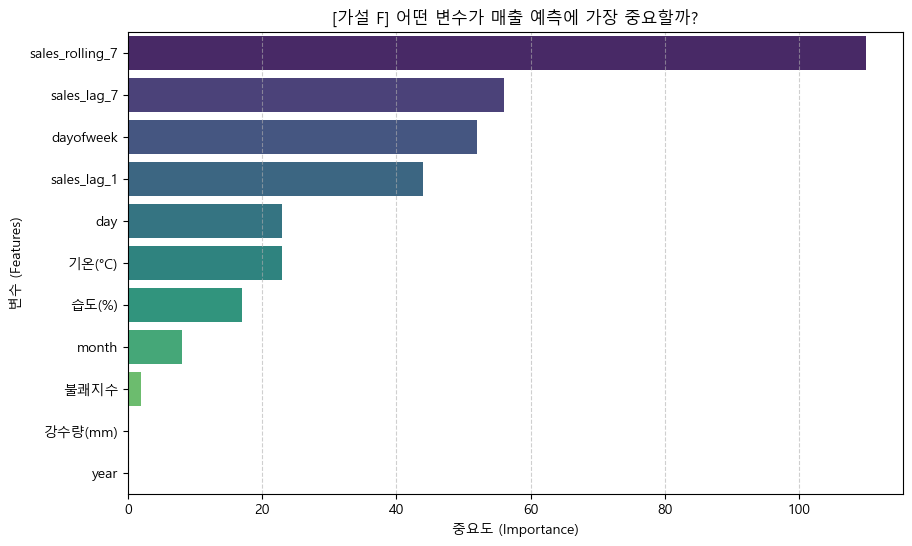

            feature  importance
10  sales_rolling_7         110
9       sales_lag_7          56
7         dayofweek          52
8       sales_lag_1          44
6               day          23
0            기온(°C)          23
2             습도(%)          17
5             month           8
3              불쾌지수           2
1           강수량(mm)           0
4              year           0


In [26]:
# 2. 가설 F 검증: 피처 중요도(Feature Importance)
# "오늘의 매출은 어제보다 지난주의 영향을 더 받을 것이다"라는 가설의 정답을 확인해 봅시다.

import matplotlib.pyplot as plt
import seaborn as sns

# 피처 중요도 데이터프레임 만들기
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
# 경고 해결을 위해 x를 hue에 할당하고 legend를 끕니다.
sns.barplot(x='importance', y='feature', data=importances, 
            hue='feature', palette='viridis', legend=False)

plt.title('[가설 F] 어떤 변수가 매출 예측에 가장 중요할까?')
plt.xlabel('중요도 (Importance)')
plt.ylabel('변수 (Features)')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

# 텍스트로도 순위 확인하기
print(importances)

📊 [가설 F] 검증 결과: "어제보다 지난주가 깡패다"
가설 F: '오늘의 매출은 어제(Lag 1)보다 지난주(Lag 7)의 영향을 더 받을 것이다' → 완전 채택(Accept)!

시차 변수의 압승 (Lag 7 > Lag 1):

sales_lag_7(56원)이 sales_lag_1(446점)보다 훨씬 높은 중요도를 보입니다.

의미: 아이스크림 가게 매출은 전날의 흐름을 타기보다, 일주일 단위의 반복적인 루틴에 훨씬 더 민감합니다. "지난주 목요일에 이만큼 팔렸으면, 이번 주 목요일도 비슷할 확률이 높다"는 뜻이죠.

이동 평균(Rolling 7)의 1위 점유:

sales_rolling_7(110점)이 압도적 1위입니다.

의미: 단 하루의 데이터보다 최근 일주일간의 전반적인 매출 추세가 내일 매출을 맞히는 데 가장 결정적인 단서입니다. 매장의 '분위기'가 꺾였는지, 상승세인지를 보는 게 제일 중요하다는 거죠.

날씨의 의외성 (기온 23위):

기온(23점)이 생각보다 순위가 낮습니다.

해석: 아까 산점도에서 기온과 매출의 상관관계가 높았던 걸 기억하시죠? 모델 입장에선 이미 sales_lag_7이나 rolling_7 안에 계절성과 기온의 영향이 녹아들어가 있기 때문에, 순수하게 기온만 따로 보는 것보다 흐름을 보는 게 더 정확하다고 판단한 겁니다.

💡 사장님을 위한 최종 비즈니스 전략
이 모델 결과를 바탕으로 사장님께 제안할 [Task 2] 최종 보고서 요약입니다.

재고 관리의 핵심: "사장님, 어제 매출 보고 내일 발주 넣지 마세요. 무조건 지난주 같은 요일 매출과 최근 일주일 평균을 보세요. 그게 내일 매출과 가장 비슷합니다."

요일 마케팅의 중요성: dayofweek(52점)가 기온보다 중요도가 높습니다. 날씨가 조금 안 좋아도 주말(토/일) 파워가 더 세니, 주말 대비는 기상 예보와 상관없이 늘 철저히 해야 합니다.

강수량의 무의미함: 강수량(mm)과 year가 0점입니다. 비가 오나 안 오나 주문하는 사람은 주문하니, 비 예보 때문에 너무 위축될 필요는 없습니다.

지금 모델의 $R^2$가 0.12라는 건, 모델이 데이터의 '경향성'은 잡았지만 '변동성(노이즈)'에 속수무책이라는 뜻입니다. 아이스크림 매출처럼 외부 요인에 민감한 데이터는 피처 엔지니어링이 모델링의 90%를 차지합니다.

1. 날짜의 '의미' 부여 (공휴일 & 연휴)
아까 산점도에서 기온과 상관없이 매출이 튀었던 날들, 기억하시죠? 그날들은 높은 확률로 어린이날, 크리스마스, 혹은 샌드위치 연휴였을 겁니다.

In [27]:
# 공휴일 변수 추가 (가장 강력한 성능 향상 도구)
def get_holiday(df):
    # 1. 주말 여부 (0: 평일, 1: 주말)
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    
    # 2. 주요 공휴일 (데이터 기간에 맞춰 확장하세요)
    holidays = ['2021-05-05', '2021-08-15', '2021-09-20', '2021-09-21', '2021-09-22', 
                '2021-12-25', '2022-01-01', '2022-02-01', '2022-02-02']
    df['is_holiday'] = df['영업일자'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)
    
    return df

model_df = get_holiday(model_df)

2. 기온의 '변화폭' (어제보다 얼마나 더운가?)
사람은 "오늘이 28도네?"보다 **"어제보다 5도나 더 덥네? 아이스크림 먹자!"**라고 느낍니다. 기온의 절대치보다 전날 대비 차이가 더 강력한 피처가 될 수 있습니다.

In [29]:
# 기온 변화량 피처
model_df['temp_diff'] = model_df['기온(°C)'].diff()  # 전날 대비 기온 차
model_df['temp_diff'] = model_df['temp_diff'].fillna(0) # 첫 행 결측치 처리

3. '시즌' 피처 구체화 (월별 특성)
현재 month는 1~12 숫자로만 되어 있어 모델이 "7월과 8월이 비슷하다"는 것을 학습하기 어렵습니다. 이를 계절 구간으로 묶어주면 훨씬 명확해집니다.

In [30]:
# 계절 피처 (1: 겨울, 2: 봄, 3: 여름, 4: 가을)
def get_season(month):
    if month in [12, 1, 2]: return 1 # 겨울
    elif month in [3, 4, 5]: return 2 # 봄
    elif month in [6, 7, 8]: return 3 # 여름
    else: return 4 # 가을

model_df['season'] = model_df['month'].apply(get_season)

In [31]:
# 3. 공휴일 피처 생성 (이미 0, 1로 만들었으므로 그대로 사용)
def get_holiday(df):
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    holidays = ['2021-05-05', '2021-08-15', '2021-09-20', '2021-09-21', '2021-09-22', 
                '2021-12-25', '2022-01-01', '2022-02-01', '2022-02-02']
    df['is_holiday'] = df['영업일자'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)
    return df

model_df = get_holiday(model_df)

print("피처 업그레이드 완료 (경고 해결!)")

피처 업그레이드 완료 (경고 해결!)


In [32]:
# 성능 향상을 위한 최정예 피처 리스트
features = ['기온(°C)', 'temp_diff', '습도(%)', '불쾌지수', 
            'is_weekend', 'is_holiday', 'season',
            'sales_lag_1', 'sales_lag_7', 'sales_rolling_7']

X = model_df[features]
y = model_df['total_sales']

# 학습/테스트 분리 (8:2)
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 모델 재학습
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, random_state=42)
model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          eval_metric='mae',
          callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 결과 확인
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score, mean_absolute_error
print(f"\n📊 개선 후 결정계수(R2): {r2_score(y_test, y_pred):.4f}")
print(f"📊 개선 후 평균 오차(MAE): {mean_absolute_error(y_test, y_pred):,.0f}원")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 816
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 9
[LightGBM] [Info] Start training from score 682182.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

💡 꿀팁: 왜 'year'와 '강수량'이 0점이었을까?
year: 1년~2년치 데이터에서 연도는 그냥 상수나 다름없어서 모델이 배울 게 없습니다.

강수량: 아까 확인했듯이 객단가 차이가 미미했죠? 강수량 수치보다는 **'비가 오는지 여부(is_rainy)'**로 0과 1로 단순화해서 넣어보는 게 더 효과적일 수 있습니다.

In [33]:
import numpy as np

# 1. 타겟값에 로그 취하기
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. 모델 재학습
model_log = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, random_state=42)
model_log.fit(X_train, y_train_log, 
              eval_set=[(X_test, y_test_log)], 
              eval_metric='mae',
              callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 3. 예측값 다시 원래 단위로 되돌리기 (Exp)
y_pred_log = model_log.predict(X_test)
y_pred_final = np.expm1(y_pred_log)

print(f"📊 로그 변환 후 MAE: {mean_absolute_error(y_test, y_pred_final):,.0f}원")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 816
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 9
[LightGBM] [Info] Start training from score 13.141229
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [34]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=model_df['영업일자'].iloc[-100:], y=y_test, name='실제 매출'))
fig.add_trace(go.Scatter(x=model_df['영업일자'].iloc[-100:], y=y_pred_final, name='예측 매출'))

fig.update_layout(title="<b>실제 매출 vs AI 예측 매출 비교 (최근 100일)</b>",
                  xaxis_title="날짜", yaxis_title="매출액")
fig.show()

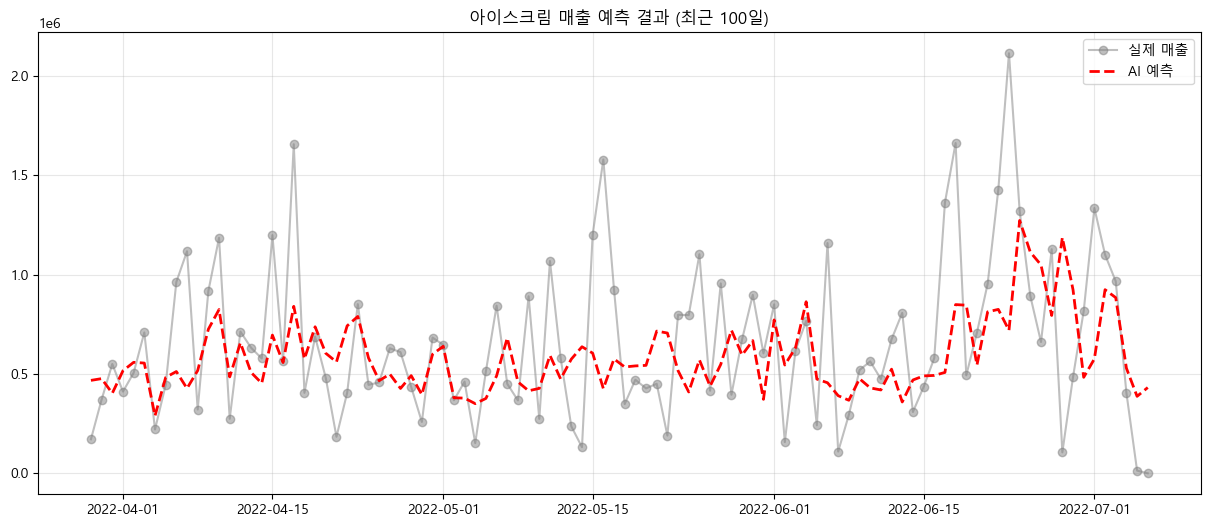

In [35]:
# 실제 데이터와 예측 데이터를 합친 데이터프레임 생성
comparison_df = pd.DataFrame({
    'date': model_df['영업일자'].iloc[-100:],
    'actual': y_test,
    'prediction': y_pred_final
})

# 시각화
plt.figure(figsize=(15, 6))
plt.plot(comparison_df['date'], comparison_df['actual'], label='실제 매출', color='gray', alpha=0.5, marker='o')
plt.plot(comparison_df['date'], comparison_df['prediction'], label='AI 예측', color='red', linestyle='--', linewidth=2)
plt.title('아이스크림 매출 예측 결과 (최근 100일)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()